# BBC Articles Multi-Class Classification: Individual Sports

Sport classification by individual sport

how it works:

- Read ds
- Keep only sport articles
- Extract the sport label from the BBC URL path
- Remove generic `/sport/articles/...` pages because they are not a single sport
- unify title + text = combined_text
- divide datas in train/validation/test with a custom split that keeps every discovered sport in training
- during inference, if the best sport probability is below 0.75, return `non-sport`

TEXT VECTORIZATION

it doesnt use the text as string BUT it converts it in numbers.

- lowercase, without accents, REMOVE 'the/and/is...'
- ngram_range=(1,2) -> single and couple worlds 'premier league, grand slam, rugby world cup...'
- makes common worls across every article weight less ('the/is...')
- makes sport-specific worlds weight MORE ('goal', 'wicket', 'serve', 'scrum', 'pole position'...)

EXAMPLE:

- vocabulary: [goal, wicket, serve, scrum] -> [0.82, 0.10, 0.00, 0.67]
- If some vocabulary has high values, the model can understand which sport is more likely.


## 1. Setup

In [1]:
# !pip install pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)
from sklearn.neural_network import MLPClassifier


RANDOM_STATE = 42
SPORT_CONFIDENCE_THRESHOLD = 0.75

np.random.seed(RANDOM_STATE)


## 2. Load and view ds

In [2]:
DATA_PATH = 'bbc_articles.csv'

df = pd.read_csv(DATA_PATH, sep=';')

print(f'Dataset shape: {df.shape}')
display(df.head(3))
print('\nOriginal category distribution:')
print(df['category'].value_counts())


Dataset shape: (2000, 4)


,title,text,category,url
0,Norwich's Sargent completes move to Toronto,Josh Sargent scored 56 goals in 157 appearance...,sport,https://www.bbc.com/sport/football/articles/c9...
1,Arsenal's Smith out of Canada squad with concu...,Olivia Smith started Arsenal's FA Cup fifth-ro...,sport,https://www.bbc.com/sport/football/articles/cd...
2,Gordon needs to stay 'fully focused' after Ars...,Anthony Gordon has scored 14 goals for Newcast...,sport,https://www.bbc.com/sport/football/articles/cn...



Original category distribution:
category
sport        1000
non-sport    1000
Name: count, dtype: int64


## 3. Multi-class target and text preparation

In [3]:
def extract_sport_label(url):
    parts = [part for part in urlparse(url).path.split('/') if part]
    if len(parts) >= 2 and parts[0] == 'sport':
        return parts[1]
    return np.nan


# keep only sport rows for the multi-class task
df = df[df['category'] == 'sport'].copy()

# derive the sport from the BBC sport section in the URL
df['sport_label'] = df['url'].apply(extract_sport_label)

# remove generic BBC sport landing pages because they are not a single sport
df = df[df['sport_label'].notna()].copy()
df = df[df['sport_label'] != 'articles'].copy()

# combine title + text for a richer input
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')
df['combined_text'] = (df['title'] + ' ' + df['text']).str.strip()

class_counts = df['sport_label'].value_counts().sort_values(ascending=False)
class_names = sorted(df['sport_label'].unique())
label_to_id = {label: idx for idx, label in enumerate(class_names)}
id_to_label = {idx: label for label, idx in label_to_id.items()}
df['label'] = df['sport_label'].map(label_to_id)

print(f'Rows kept for multi-class sport classification: {len(df)}')
print(f'Number of sport classes: {len(class_names)}')
print('\nSport distribution:')
print(class_counts)
print('\nEmpty combined_text rows:', (df['combined_text'].str.len() == 0).sum())


Rows kept for multi-class sport classification: 967
Number of sport classes: 17

Sport distribution:
sport_label
football              275
cricket               208
formula1               91
rugby-union            86
tennis                 84
boxing                 70
athletics              52
golf                   38
cycling                30
netball                11
olympics                5
rugby-league            5
ice-hockey              4
snooker                 4
mixed-martial-arts      2
swimming                1
motorsport              1
Name: count, dtype: int64

Empty combined_text rows: 0


## 4. Train / Validation / Test Split

In [4]:
def split_single_class(group, random_state=RANDOM_STATE):
    shuffled = group.sample(frac=1, random_state=random_state)
    n = len(shuffled)

    if n == 1:
        train_n, val_n, test_n = 1, 0, 0
    elif n == 2:
        train_n, val_n, test_n = 1, 0, 1
    elif n == 3:
        train_n, val_n, test_n = 1, 1, 1
    elif n == 4:
        train_n, val_n, test_n = 2, 1, 1
    else:
        val_n = max(1, int(round(n * 0.20)))
        test_n = max(1, int(round(n * 0.20)))
        train_n = n - val_n - test_n

        if train_n < 1:
            train_n = 1
            if val_n >= test_n and val_n > 1:
                val_n -= 1
            else:
                test_n -= 1

    train_split = shuffled.iloc[:train_n]
    val_split = shuffled.iloc[train_n:train_n + val_n]
    test_split = shuffled.iloc[train_n + val_n:train_n + val_n + test_n]

    return train_split, val_split, test_split


train_parts = []
val_parts = []
test_parts = []

for _, group in df.groupby('sport_label', sort=False):
    train_part, val_part, test_part = split_single_class(group)
    train_parts.append(train_part)
    if len(val_part) > 0:
        val_parts.append(val_part)
    if len(test_part) > 0:
        test_parts.append(test_part)

train_df = pd.concat(train_parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
val_df = pd.concat(val_parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_df = pd.concat(test_parts).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train = train_df['combined_text']
y_train = train_df['label']

X_val = val_df['combined_text']
y_val = val_df['label']

X_test = test_df['combined_text']
y_test = test_df['label']

print(f'Train size: {len(X_train)}')
print(f'Validation size: {len(X_val)}')
print(f'Test size: {len(X_test)}')

print('\nTrain class balance:')
print(train_df['sport_label'].value_counts())

print('\nValidation class balance:')
print(val_df['sport_label'].value_counts())

print('\nTest class balance:')
print(test_df['sport_label'].value_counts())


Train size: 580
Validation size: 193
Test size: 194

Train class balance:
sport_label
football              165
cricket               124
formula1               55
rugby-union            52
tennis                 50
boxing                 42
athletics              32
golf                   22
cycling                18
netball                 7
olympics                3
rugby-league            3
snooker                 2
ice-hockey              2
mixed-martial-arts      1
motorsport              1
swimming                1
Name: count, dtype: int64

Validation class balance:
sport_label
football        55
cricket         42
formula1        18
tennis          17
rugby-union     17
boxing          14
athletics       10
golf             8
cycling          6
netball          2
rugby-league     1
olympics         1
ice-hockey       1
snooker          1
Name: count, dtype: int64

Test class balance:
sport_label
football              55
cricket               42
formula1              18
tennis 

## 5. Text Vectorization (TF-IDF)

In [5]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents='unicode',
    stop_words='english',
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print('Train TF-IDF shape:', X_train_tfidf.shape)
print('Validation TF-IDF shape:', X_val_tfidf.shape)
print('Test TF-IDF shape:', X_test_tfidf.shape)


Train TF-IDF shape: (580, 30000)
Validation TF-IDF shape: (193, 30000)
Test TF-IDF shape: (194, 30000)


## 6. Neural Network Training (MLP)

In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=1,
    warm_start=True,
    random_state=RANDOM_STATE
)

EPOCHS = 20
train_acc_history = []
val_acc_history = []

for epoch in range(EPOCHS):
    mlp.fit(X_train_tfidf, y_train)

    train_pred = mlp.predict(X_train_tfidf)
    val_pred = mlp.predict(X_val_tfidf)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f'Epoch {epoch + 1:02d}/{EPOCHS} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}')


/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 01/20 - Train Acc: 0.0052 - Val Acc: 0.0052


/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 02/20 - Train Acc: 0.1828 - Val Acc: 0.0725


/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


...

/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 18/20 - Train Acc: 0.9931 - Val Acc: 0.9689


/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Epoch 19/20 - Train Acc: 0.9948 - Val Acc: 0.9689
Epoch 20/20 - Train Acc: 0.9948 - Val Acc: 0.9741


/home/luca/anaconda3/envs/ML4DD/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Best validation accuracy: 0.9741 at epoch 20


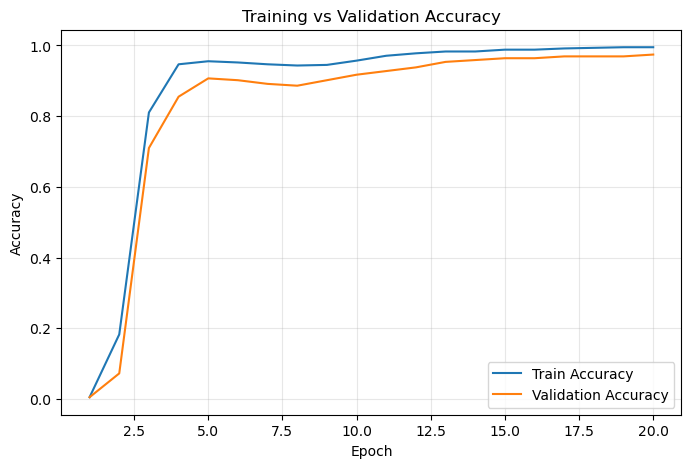

In [7]:
best_epoch = int(np.argmax(val_acc_history))
best_val_acc = val_acc_history[best_epoch]

print(f'Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch + 1}')

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, EPOCHS + 1), val_acc_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 7. Evaluation on Test Set

In [8]:
y_test_pred = mlp.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, y_test_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average='macro',
    zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)

print(f'Test Accuracy        : {test_acc:.4f}')
print(f'Test Precision Macro : {precision_macro:.4f}')
print(f'Test Recall Macro    : {recall_macro:.4f}')
print(f'Test F1-score Macro  : {f1_macro:.4f}')
print(f'Test Precision Weight: {precision_weighted:.4f}')
print(f'Test Recall Weight   : {recall_weighted:.4f}')
print(f'Test F1-score Weight : {f1_weighted:.4f}')

labels_in_test = sorted(y_test.unique())
target_names_in_test = [id_to_label[label] for label in labels_in_test]

print('\nDetailed classification report:')
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=labels_in_test,
        target_names=target_names_in_test,
        zero_division=0
    )
)


Test Accuracy        : 0.9639
Test Precision Macro : 0.7173
Test Recall Macro    : 0.6850
Test F1-score Macro  : 0.6947
Test Precision Weight: 0.9463
Test Recall Weight   : 0.9639
Test F1-score Weight : 0.9532

Detailed classification report:
                    precision    recall  f1-score   support

         athletics       0.91      1.00      0.95        10
            boxing       0.93      1.00      0.97        14
           cricket       1.00      1.00      1.00        42
           cycling       1.00      0.83      0.91         6
          football       0.92      1.00      0.96        55
          formula1       1.00      1.00      1.00        18
              golf       1.00      1.00      1.00         8
        ice-hockey       0.00      0.00      0.00         1
mixed-martial-arts       0.00      0.00      0.00         1
           netball       1.00      0.50      0.67         2
          olympics       0.00      0.00      0.00         1
      rugby-league       0.00      0

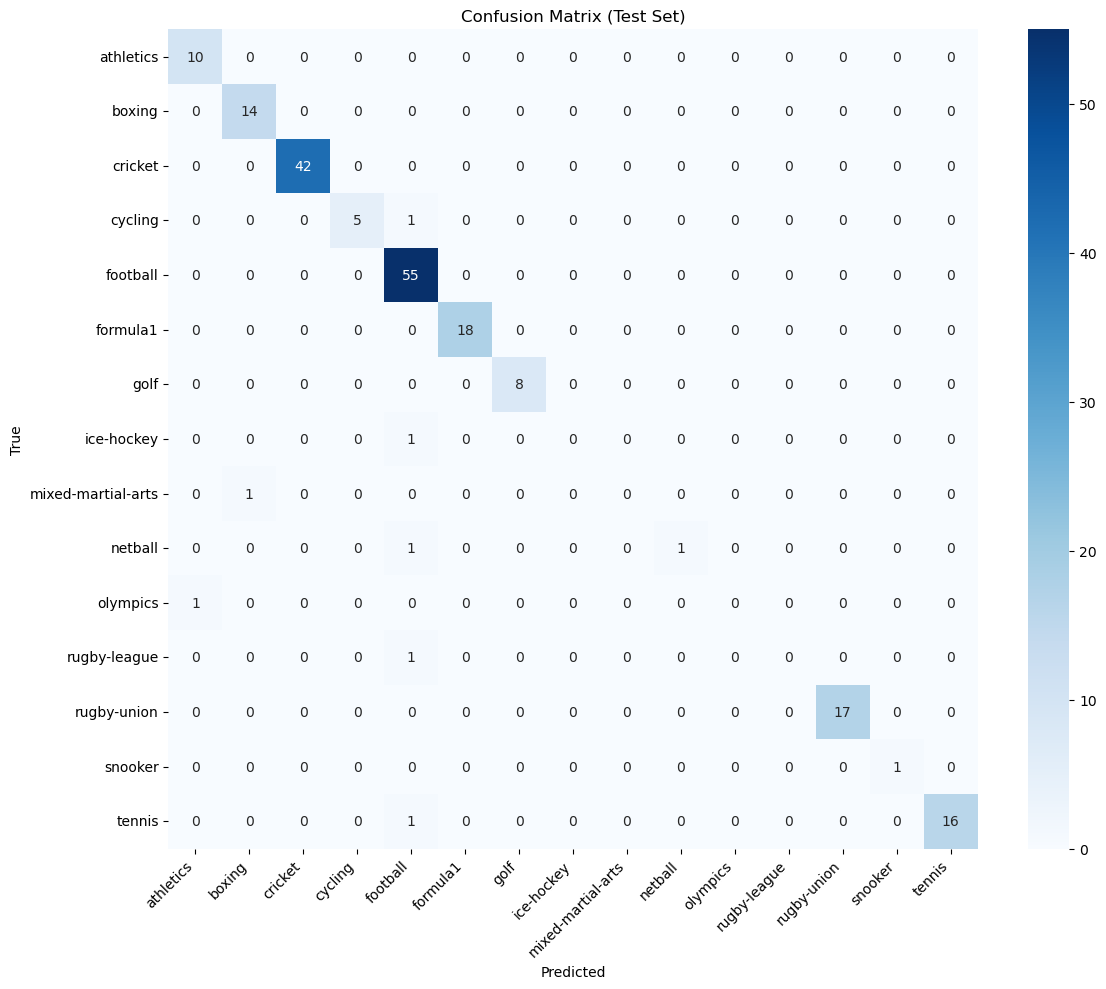

In [9]:
labels_in_test = sorted(y_test.unique())
target_names_in_test = [id_to_label[label] for label in labels_in_test]
cm = confusion_matrix(y_test, y_test_pred, labels=labels_in_test)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names_in_test,
    yticklabels=target_names_in_test
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Try New Examples

In [10]:
new_samples = [
    'Manchester United won 3-1 with a late goal in the Premier League.',
    'The batter scored a century after a dominant opening partnership in the second innings.',
    'The driver secured pole position and managed tyre wear perfectly over the final laps.',
    'She broke serve twice to win the second set and reach the quarter-final.',
    'Donald Trump just died in his house in Florida.'
]

new_tfidf = vectorizer.transform(new_samples)
new_probs = mlp.predict_proba(new_tfidf)

for text, probs in zip(new_samples, new_probs):
    top_indices = np.argsort(probs)[::-1][:3]
    best_idx = int(top_indices[0])
    best_prob = float(probs[best_idx])

    if best_prob >= SPORT_CONFIDENCE_THRESHOLD:
        predicted_label = id_to_label[best_idx]
    else:
        predicted_label = 'non-sport'

    top_predictions = ', '.join(
        f"{id_to_label[idx]}={probs[idx]:.3f}" for idx in top_indices
    )

    print(f'Text: {text}')
    print(f'Predicted label: {predicted_label}')
    print(f'Best sport confidence: {best_prob:.3f}')
    print(f'Threshold: {SPORT_CONFIDENCE_THRESHOLD:.2f}')
    print(f'Top-3 sport probabilities: {top_predictions}')
    print('-' * 80)


Text: Manchester United won 3-1 with a late goal in the Premier League.
Predicted label: non-sport
Best sport confidence: 0.678
Threshold: 0.75
Top-3 sport probabilities: football=0.678, rugby-league=0.045, rugby-union=0.037
--------------------------------------------------------------------------------
Text: The batter scored a century after a dominant opening partnership in the second innings.
Predicted label: non-sport
Best sport confidence: 0.622
Threshold: 0.75
Top-3 sport probabilities: cricket=0.622, cycling=0.054, golf=0.041
--------------------------------------------------------------------------------
Text: The driver secured pole position and managed tyre wear perfectly over the final laps.
Predicted label: non-sport
Best sport confidence: 0.251
Threshold: 0.75
Top-3 sport probabilities: formula1=0.251, rugby-league=0.077, football=0.075
--------------------------------------------------------------------------------
Text: She broke serve twice to win the second set and re